<img src="../Decorative-Elements/Section-04/ADL-S04-Image-04-f.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/04-JANUS-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/06-SEI-Integrator.ipynb" target="_blank">Next</a>
</p>

In [ ]:
# Mercurius Integrator - Important Use Case
# - Hybrid integrator combining symplectic methods and adaptive close-encounter handling.
# - Symplectic outside close encounters; switches to high-accuracy integration during encounters.
# - Ideal for planetary systems with both well-separated orbits and occasional close encounters.
# - Efficient for long-term orbital evolution while resolving rare but important interactions.
# - Commonly used in simulations of:
#     • Planets with close moon interactions
#     • Asteroid-planet encounters
#     • Cometary orbits with planetary flybys
# - Balances efficiency with accuracy in mixed-dynamics systems.

In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt

In [3]:

# Initialize simulation
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.integrator = "mercurius"   # Hybrid integrator: symplectic + adaptive close-encounter handling
sim.dt = 0.01                  # Base timestep for regular motion

# Add Sun
sim.add(m=1.0)

In [4]:
# Add Jupiter (planet for flybys)
jupiter_mass = 0.001          # Msun
jupiter_a = 5.2               # AU
sim.add(m=jupiter_mass, a=jupiter_a, e=0.0)
jupiter_index = 1
jupiter = sim.particles[jupiter_index]

# Add comet (eccentric orbit for flybys)
comet_mass = 1e-10            # Negligible mass
comet_a = 4.0                 # Semi-major axis in AU
comet_e = 0.9                 # High eccentricity for comet
sim.add(m=comet_mass, a=comet_a, e=comet_e)
comet_index = 2
comet = sim.particles[comet_index]

In [5]:
# Move to center-of-mass
sim.move_to_com()

In [6]:
# Integration parameters
years = 20
N_steps = int(years / sim.dt)

In [7]:
# Arrays to store positions and conserved quantities
comet_positions = np.zeros((N_steps,2))
jupiter_positions = np.zeros((N_steps,2))
kinetic_energy = np.zeros(N_steps)
potential_energy = np.zeros(N_steps)
total_energy = np.zeros(N_steps)
angular_momentum = np.zeros(N_steps)

In [8]:
# Energy and angular momentum functions
def compute_energy(sim):
    KE = 0.0
    PE = 0.0
    N = len(sim.particles)
    for i in range(N):
        pi = sim.particles[i]
        KE += 0.5 * pi.m * (pi.vx**2 + pi.vy**2 + pi.vz**2)
        for j in range(i+1, N):
            pj = sim.particles[j]
            dx = pi.x - pj.x
            dy = pi.y - pj.y
            dz = pi.z - pj.z
            r = np.sqrt(dx**2 + dy**2 + dz**2)
            PE -= pi.m * pj.m / r
    return KE, PE

In [9]:
def compute_angular_momentum(sim):
    Lx = Ly = Lz = 0.0
    for pi in sim.particles:
        Lx += pi.m * (pi.y*pi.vz - pi.z*pi.vy)
        Ly += pi.m * (pi.z*pi.vx - pi.x*pi.vz)
        Lz += pi.m * (pi.x*pi.vy - pi.y*pi.vx)
    return np.sqrt(Lx**2 + Ly**2 + Lz**2)

In [10]:
# Integration loop
for i in range(N_steps):
    sim.integrate(sim.t + sim.dt)
    
    # Store positions
    comet_positions[i] = [comet.x, comet.y]
    jupiter_positions[i] = [jupiter.x, jupiter.y]
    
    # Compute energies and angular momentum
    KE, PE = compute_energy(sim)
    kinetic_energy[i] = KE
    potential_energy[i] = PE
    total_energy[i] = KE + PE
    angular_momentum[i] = compute_angular_momentum(sim)

In [18]:
# Function to return calculated values for inspection
def get_conservation_data(n_values=10):
    """
    Returns the first `n_values` of energy and angular momentum for inspection.
    """
    data = []
    for i in range(min(n_values, N_steps)):
        data.append({
            'step': i,
            'kinetic_energy': kinetic_energy[i],
            'potential_energy': potential_energy[i],
            'total_energy': total_energy[i],
            'angular_momentum': angular_momentum[i]
        })
    return data

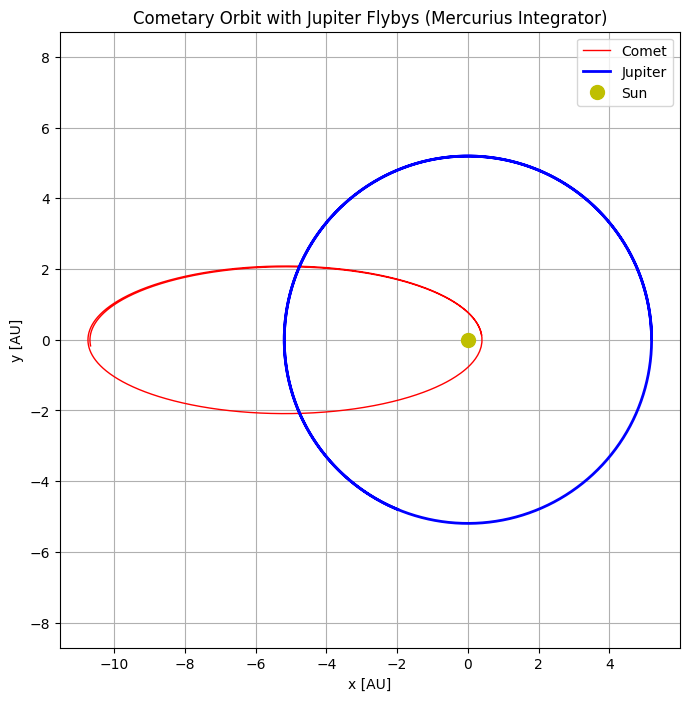

In [13]:
# Plot orbits
plt.figure(figsize=(8,8))
plt.plot(comet_positions[:,0], comet_positions[:,1], color='red', lw=1, label='Comet')
plt.plot(jupiter_positions[:,0], jupiter_positions[:,1], color='blue', lw=2, label='Jupiter')
plt.plot(0,0,'yo', markersize=10, label='Sun')
plt.xlabel('x [AU]')
plt.ylabel('y [AU]')
plt.title('Cometary Orbit with Jupiter Flybys (Mercurius Integrator)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

In [19]:
# Example: get first 10 conservation values
conservation_sample = get_conservation_data(10)
for entry in conservation_sample:
    print(entry)

{'step': 0, 'kinetic_energy': np.float64(0.003795867438595768), 'potential_energy': np.float64(-0.00019230793263119936), 'total_energy': np.float64(0.0036035595059645685), 'angular_momentum': np.float64(0.01432043847598359)}
{'step': 1, 'kinetic_energy': np.float64(0.003795866787084866), 'potential_energy': np.float64(-0.00019230791612782463), 'total_energy': np.float64(0.0036035588709570415), 'angular_momentum': np.float64(0.01432043847598359)}
{'step': 2, 'kinetic_energy': np.float64(0.0037958659709359474), 'potential_energy': np.float64(-0.0001923078954538975), 'total_energy': np.float64(0.00360355807548205), 'angular_momentum': np.float64(0.014320438475983594)}
{'step': 3, 'kinetic_energy': np.float64(0.0037958651632373865), 'potential_energy': np.float64(-0.00019230787499394138), 'total_energy': np.float64(0.003603557288243445), 'angular_momentum': np.float64(0.014320438475983594)}
{'step': 4, 'kinetic_energy': np.float64(0.003795864441639286), 'potential_energy': np.float64(-0.00

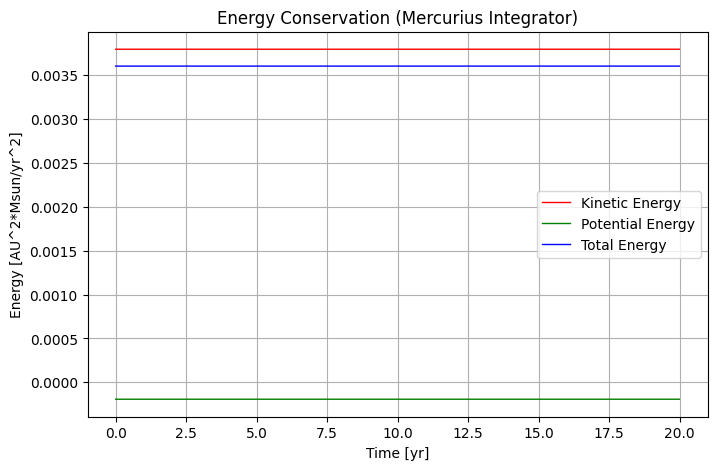

In [17]:
# Plot energy conservation
plt.figure(figsize=(8,5))
plt.plot(np.arange(N_steps)*sim.dt, kinetic_energy, label='Kinetic Energy', color='red', lw=1)
plt.plot(np.arange(N_steps)*sim.dt, potential_energy, label='Potential Energy', color='green', lw=1)
plt.plot(np.arange(N_steps)*sim.dt, total_energy, label='Total Energy', color='blue', lw=1)
plt.xlabel('Time [yr]')
plt.ylabel('Energy [AU^2*Msun/yr^2]')
plt.title('Energy Conservation (Mercurius Integrator)')
plt.grid(True)
plt.legend()
plt.show()

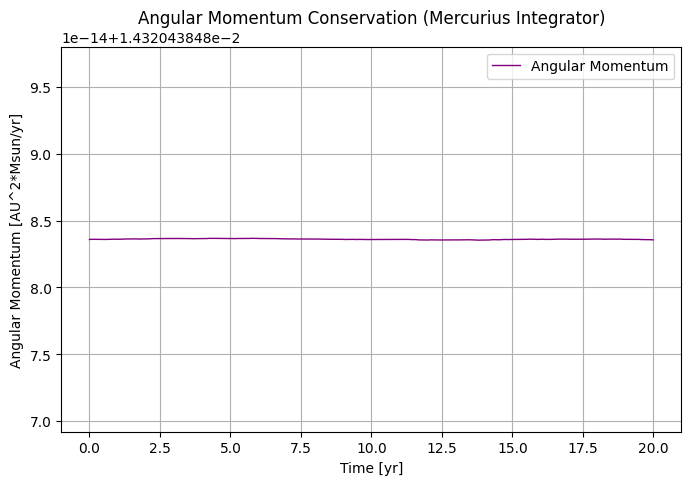

In [15]:
# Plot angular momentum conservation
plt.figure(figsize=(8,5))
plt.plot(np.arange(N_steps)*sim.dt, angular_momentum, label='Angular Momentum', color='purple', lw=1)
plt.xlabel('Time [yr]')
plt.ylabel('Angular Momentum [AU^2*Msun/yr]')
plt.title('Angular Momentum Conservation (Mercurius Integrator)')
plt.grid(True)
plt.legend()
plt.show()

In [20]:
# CODE EXPLANATION

# 1. Simulation Initialization
# - We create a REBOUND Simulation instance.
# - Units: AU for distance, yr for time, Msun for mass.
# - Integrator: 'mercurius' is a hybrid symplectic integrator, ideal for systems with
#   mostly regular motion but occasional close encounters (like cometary flybys).
# - Base timestep dt=0.01 yr is used for normal motion; Mercurius adapts during close encounters.

# 2. Adding Bodies
# - Sun: central massive body at origin.
# - Jupiter: a planet on a circular orbit at 5.2 AU, acts as a flyby target for the comet.
# - Comet: very small mass (effectively test particle), high eccentricity orbit (e=0.9),
#   semi-major axis 4 AU, designed to have repeated close approaches with Jupiter.

# 3. Center-of-Mass Adjustment
# - sim.move_to_com() ensures the system is in the center-of-mass frame for accurate orbital dynamics.

# 4. Integration Parameters
# - Total simulation time = 20 years.
# - N_steps calculated based on base timestep dt.
# - Arrays initialized to store positions of comet and Jupiter, kinetic, potential, total energy, and angular momentum.

# 5. Energy and Angular Momentum Functions
# - compute_energy(sim): manually computes total kinetic and potential energy of all particles.
# - compute_angular_momentum(sim): manually computes total angular momentum magnitude.
# - These are used because hybrid integrators like Mercurius do not provide built-in energy/momentum functions.

# 6. Integration Loop
# - For each timestep:
#     a) Integrate simulation by dt.
#     b) Record comet and Jupiter positions.
#     c) Compute KE, PE, total energy, and angular momentum.
# - This loop tracks the comet orbit, Jupiter orbit, and checks conservation laws.

# 7. get_conservation_data(n)
# - Independent function that returns the first n steps of computed KE, PE, total energy, and angular momentum.
# - Useful for printing, debugging, or verifying conservation values without plotting.

# 8. Orbit Plotting
# - Plot comet orbit in red and Jupiter orbit in blue.
# - Sun marked as yellow at the origin.
# - Shows cometary flybys and overall trajectory in 2D.

# 9. Energy Conservation Plot
# - Plots kinetic, potential, and total energy over time.
# - Confirms that total energy is largely conserved, even during close encounters, thanks to Mercurius.

# 10. Angular Momentum Conservation Plot
# - Plots total angular momentum magnitude over time.
# - Checks that angular momentum is conserved (as expected in a closed gravitational system).

# SUMMARY
# - The code simulates a comet repeatedly flying by Jupiter in a hybrid N-body simulation.
# - Mercurius allows accurate treatment of close encounters while being efficient for the rest of the orbit.
# - Energy and angular momentum are manually computed and plotted to verify conservation.
# - The get_conservation_data function provides numerical values for inspection.

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/04-JANUS-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/06-SEI-Integrator.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-04-05.gif">